In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Base path ──────────────────────────────────────────────
BASE = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye/datasets'

# ── Paths ──────────────────────────────────────────────────
ROP_IMAGES  = os.path.join(BASE, 'images_stack_without_captions',
                                 'images_stack_without_captions')
ROP_CSV     = os.path.join(BASE, 'infant_retinal_database_info.csv')
CATARACT    = os.path.join(BASE, 'dataset', 'cataract')
NORMAL      = os.path.join(BASE, 'dataset', 'normal')

# ── Verify ─────────────────────────────────────────────────
print("=" * 55)
print("   NEOSCAN AI — MODULE 3 DATASET VERIFICATION")
print("=" * 55)

checks = {
    "ROP Images Folder"   : ROP_IMAGES,
    "ROP CSV Label File"  : ROP_CSV,
    "Cataract Folder"     : CATARACT,
    "Normal Eyes Folder"  : NORMAL,
}

all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    status = "✅ FOUND" if exists else "❌ MISSING"
    print(f"  {status}  →  {name}")
    if not exists:
        all_ok = False

print("=" * 55)

# ── Count files ────────────────────────────────────────────
if all_ok:
    rop_count      = len(os.listdir(ROP_IMAGES))
    cataract_count = len(os.listdir(CATARACT))
    normal_count   = len(os.listdir(NORMAL))

    print("\n📊 IMAGE COUNTS:")
    print(f"  ROP Images (images_stack_without_captions) : {rop_count}")
    print(f"  Cataract Images                            : {cataract_count}")
    print(f"  Normal Eye Images                          : {normal_count}")
    print(f"  TOTAL                                      : {rop_count + cataract_count + normal_count}")
    print("\n✅ All folders found! Ready for preprocessing.")
else:
    print("\n❌ Some folders are MISSING.")
    print("   Check your Google Drive folder structure and re-upload.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   NEOSCAN AI — MODULE 3 DATASET VERIFICATION
  ✅ FOUND  →  ROP Images Folder
  ✅ FOUND  →  ROP CSV Label File
  ✅ FOUND  →  Cataract Folder
  ✅ FOUND  →  Normal Eyes Folder

📊 IMAGE COUNTS:
  ROP Images (images_stack_without_captions) : 6004
  Cataract Images                            : 1038
  Normal Eye Images                          : 1074
  TOTAL                                      : 8116

✅ All folders found! Ready for preprocessing.


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 2 - Read CSV & Map ROP Stage Labels
# ============================================================

import pandas as pd

BASE    = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye/datasets'
ROP_CSV = os.path.join(BASE, 'infant_retinal_database_info.csv')

# ── Load CSV ────────────────────────────────────────────────
df = pd.read_csv(ROP_CSV, sep=';')
print("✅ CSV Loaded Successfully!")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns Found:\n   {list(df.columns)}")
print(f"\n🔍 First 5 rows:")
print(df.head())

# ── Check Diagnosis Code distribution ───────────────────────
print("\n📊 DIAGNOSIS CODE (DG) Distribution:")
print(df['DIAGNOSIS CODE (DG)'].value_counts().sort_index())

✅ CSV Loaded Successfully!
   Shape: 484 rows × 9 columns

📋 Columns Found:
   ['ID', 'SEX', 'GESTATIONAL AGE (GA)', 'BIRTH WEIGHT (BW)', 'POSTCONCEPTUAL AGE (PA)', 'DIAGNOSIS CODE (DG)', 'PLUS FORM (PF)', 'DEVICE (D)', 'SERIE NUMBER (S)']

🔍 First 5 rows:
   ID SEX  GESTATIONAL AGE (GA)  BIRTH WEIGHT (BW)  POSTCONCEPTUAL AGE (PA)  \
0   1   F                    41               2905                     44.0   
1   1   F                    41               2905                     47.0   
2   1   F                    41               2905                     50.0   
3   2   M                    40               4040                     41.0   
4   2   M                    40               4040                     43.0   

   DIAGNOSIS CODE (DG)  PLUS FORM (PF)  DEVICE (D)  SERIE NUMBER (S)  
0                   11               0           1                 1  
1                   11               0           1                 2  
2                   11               0           1     

In [ ]:
# ============================================================
# CELL 3 - Inspect Image Filenames to understand naming pattern
# ============================================================

import os

ROP_IMAGES = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye/datasets/images_stack_without_captions/images_stack_without_captions'

# Show first 20 image filenames
all_files = sorted(os.listdir(ROP_IMAGES))
print(f"Total files: {len(all_files)}")
print("\n📋 First 20 filenames:")
for f in all_files[:20]:
    print(f"  {f}")

print("\n📋 Last 5 filenames:")
for f in all_files[-5:]:
    print(f"  {f}")

Total files: 6004

📋 First 20 filenames:
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_1.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_10.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_11.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_12.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_2.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_3.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_4.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_5.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_6.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_7.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_8.jpg
  001_F_GA41_BW2905_PA44_DG11_PF0_D1_S01_9.jpg
  001_F_GA41_BW2905_PA47_DG11_PF0_D1_S02_1.jpg
  001_F_GA41_BW2905_PA47_DG11_PF0_D1_S02_10.jpg
  001_F_GA41_BW2905_PA47_DG11_PF0_D1_S02_11.jpg
  001_F_GA41_BW2905_PA47_DG11_PF0_D1_S02_12.jpg
  001_F_GA41_BW2905_PA47_DG11_PF0_D1_S02_13.jpg
  001_F_GA41_BW2905_PA47_DG11_PF0_D1_S02_14.jpg
  001_F_GA41_BW2905_PA47_DG11_PF0_D1_S02_15.jpg
  001_F_GA41_BW2905_PA47_DG11_PF0_D1_S02_16.jpg

📋 Last 5

In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 4 - Extract Labels from Filenames & Map to ROP Classes
# ============================================================

import os
import pandas as pd
import re
from collections import Counter

ROP_IMAGES = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye/datasets/images_stack_without_captions/images_stack_without_captions'

# ── Step 1: Extract DG code from every filename ─────────────
all_files = sorted(os.listdir(ROP_IMAGES))

records = []
for fname in all_files:
    match = re.search(r'_DG(\d+)_', fname)
    if match:
        dg = int(match.group(1))
        records.append({'filename': fname, 'DG': dg})

df_files = pd.DataFrame(records)
print(f"✅ Extracted labels from {len(df_files)} images")
print(f"\n📊 Raw DG Distribution across all images:")
print(df_files['DG'].value_counts().sort_index())

# ── Step 2: Map DG codes to our 5 ROP classes ───────────────
# Keep only ROP-relevant classes, skip hemorrhage/toxoplasma etc.

CLASS_MAP = {
    0:  'stage_0_normal',   # Physiological
    1:  'stage_0_normal',   # ROP Stage 0
    2:  'stage_1',          # ROP Stage 1
    3:  'stage_2',          # ROP Stage 2
    4:  'stage_3',          # ROP Stage 3
    8:  'stage_3',          # AP-ROP → merge with Stage 3
}

SKIP_CODES = [9, 10, 11, 12, 13]  # Post-treatment, hemorrhage, etc.

df_files['class_label'] = df_files['DG'].map(CLASS_MAP)
df_rop = df_files[df_files['DG'].isin(CLASS_MAP.keys())].copy()
df_skip = df_files[df_files['DG'].isin(SKIP_CODES)]

print(f"\n✅ Images kept for ROP training : {len(df_rop)}")
print(f"❌ Images skipped (irrelevant)  : {len(df_skip)}")

print(f"\n📊 FINAL CLASS DISTRIBUTION:")
class_counts = df_rop['class_label'].value_counts()
for cls, count in sorted(class_counts.items()):
    bar = '█' * (count // 20)
    print(f"  {cls:<20} : {count:>4} images  {bar}")

# ── Save for next step ──────────────────────────────────────
df_rop.to_csv('/content/drive/MyDrive/NeoScan_AI/Module3_Eye/rop_labels.csv', index=False)
print(f"\n✅ ROP label file saved → rop_labels.csv")

✅ Extracted labels from 6004 images

📊 Raw DG Distribution across all images:
DG
0     2980
1       45
2      252
3      458
4      125
8      470
9      379
10      72
11    1061
12      48
13     114
Name: count, dtype: int64

✅ Images kept for ROP training : 4330
❌ Images skipped (irrelevant)  : 1674

📊 FINAL CLASS DISTRIBUTION:
  stage_0_normal       : 3025 images  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  stage_1              :  252 images  ████████████
  stage_2              :  458 images  ██████████████████████
  stage_3              :  595 images  █████████████████████████████

✅ ROP label file saved → rop_labels.csv


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 5 - Fix Class Imbalance & Build Final Unified Dataset
# ============================================================

import os
import pandas as pd
import shutil
from sklearn.utils import resample

# ── Paths ───────────────────────────────────────────────────
BASE       = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
ROP_IMAGES = os.path.join(BASE, 'datasets/images_stack_without_captions/images_stack_without_captions')
CATARACT   = os.path.join(BASE, 'datasets/dataset/cataract')
NORMAL_EYE = os.path.join(BASE, 'datasets/dataset/normal')
OUTPUT_DIR = os.path.join(BASE, 'final_dataset')

# ── Load ROP labels ─────────────────────────────────────────
df_rop = pd.read_csv(os.path.join(BASE, 'rop_labels.csv'))

# ── Step 1: Downsample Stage 0 to max 600 images ────────────
MAX_PER_CLASS = 600

df_stage0 = df_rop[df_rop['class_label'] == 'stage_0_normal']
df_stage1 = df_rop[df_rop['class_label'] == 'stage_1']
df_stage2 = df_rop[df_rop['class_label'] == 'stage_2']
df_stage3 = df_rop[df_rop['class_label'] == 'stage_3']

# Downsample stage 0
df_stage0_down = resample(df_stage0,
                          n_samples=MAX_PER_CLASS,
                          random_state=42,
                          replace=False)

print("📊 ROP Classes After Balancing:")
print(f"  stage_0_normal : {len(df_stage0_down)}")
print(f"  stage_1        : {len(df_stage1)}")
print(f"  stage_2        : {len(df_stage2)}")
print(f"  stage_3        : {len(df_stage3)}")

# ── Step 2: Build Cataract & Normal dataframes ──────────────
def build_df(folder, label):
    files = os.listdir(folder)
    return pd.DataFrame({
        'filename': [os.path.join(folder, f) for f in files],
        'class_label': label,
        'source': 'eye_diseases'
    })

df_cataract   = build_df(CATARACT,   'cataract')
df_normal_eye = build_df(NORMAL_EYE, 'normal_eye')

# Downsample cataract and normal to 600 too
df_cataract_down   = resample(df_cataract,   n_samples=MAX_PER_CLASS, random_state=42, replace=False)
df_normal_eye_down = resample(df_normal_eye, n_samples=MAX_PER_CLASS, random_state=42, replace=False)

print(f"\n📊 Eye Disease Classes After Balancing:")
print(f"  cataract   : {len(df_cataract_down)}")
print(f"  normal_eye : {len(df_normal_eye_down)}")

# ── Step 3: Add full path to ROP rows ───────────────────────
df_stage0_down = df_stage0_down.copy()
df_stage1      = df_stage1.copy()
df_stage2      = df_stage2.copy()
df_stage3      = df_stage3.copy()

for df_ in [df_stage0_down, df_stage1, df_stage2, df_stage3]:
    df_['filename'] = df_['filename'].apply(lambda f: os.path.join(ROP_IMAGES, f))
    df_['source']   = 'rop'

# ── Step 4: Combine all classes ─────────────────────────────
df_final = pd.concat([
    df_stage0_down[['filename','class_label','source']],
    df_stage1     [['filename','class_label','source']],
    df_stage2     [['filename','class_label','source']],
    df_stage3     [['filename','class_label','source']],
    df_cataract_down,
    df_normal_eye_down,
], ignore_index=True)

# Shuffle
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ FINAL UNIFIED DATASET:")
print(df_final['class_label'].value_counts())
print(f"\n  TOTAL IMAGES : {len(df_final)}")

# ── Save master CSV ─────────────────────────────────────────
save_path = os.path.join(BASE, 'master_dataset.csv')
df_final.to_csv(save_path, index=False)
print(f"\n✅ Master dataset saved → master_dataset.csv")

📊 ROP Classes After Balancing:
  stage_0_normal : 600
  stage_1        : 252
  stage_2        : 458
  stage_3        : 595

📊 Eye Disease Classes After Balancing:
  cataract   : 600
  normal_eye : 600

✅ FINAL UNIFIED DATASET:
class_label
stage_0_normal    600
normal_eye        600
cataract          600
stage_3           595
stage_2           458
stage_1           252
Name: count, dtype: int64

  TOTAL IMAGES : 3105

✅ Master dataset saved → master_dataset.csv


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 6 - Ben Graham Preprocessing + CLAHE + Resize 299x299
# ============================================================

# ── Install & Import ────────────────────────────────────────
import cv2
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

BASE       = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
PROCESSED  = os.path.join(BASE, 'processed_dataset')
df_final   = pd.read_csv(os.path.join(BASE, 'master_dataset.csv'))

# ── Create output folders ───────────────────────────────────
classes = df_final['class_label'].unique()
for cls in classes:
    os.makedirs(os.path.join(PROCESSED, cls), exist_ok=True)
print(f"✅ Output folders created: {list(classes)}")

# ── Ben Graham Preprocessing Function ───────────────────────
def ben_graham(img, sigmaX=10):
    """
    Ben Graham method:
    Circular crop + subtract local mean to enhance retinal features
    """
    img = cv2.resize(img, (299, 299))
    img = cv2.addWeighted(
        img, 4,
        cv2.GaussianBlur(img, (0, 0), sigmaX), -4,
        128
    )
    return img

# ── CLAHE Enhancement Function ───────────────────────────────
def apply_clahe(img):
    """
    CLAHE on L channel of LAB colorspace
    Enhances retinal vessel contrast
    """
    lab   = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l     = clahe.apply(l)
    lab   = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# ── Full Preprocessing Pipeline ──────────────────────────────
def preprocess_image(img_path, source):
    img = cv2.imread(img_path)
    if img is None:
        return None

    if source == 'rop':
        # ROP retinal images: Ben Graham + CLAHE
        img = ben_graham(img)
        img = apply_clahe(img)
    else:
        # Cataract/Normal external eye photos: just resize + CLAHE
        img = cv2.resize(img, (299, 299))
        img = apply_clahe(img)

    return img

# ── Process All Images ───────────────────────────────────────
success = 0
failed  = 0

print(f"\n🔄 Processing {len(df_final)} images...")
print("   This will take a few minutes...\n")

for _, row in tqdm(df_final.iterrows(), total=len(df_final)):
    img_path    = row['filename']
    class_label = row['class_label']
    source      = row['source']

    processed = preprocess_image(img_path, source)

    if processed is not None:
        # Save with original filename
        fname    = os.path.basename(img_path)
        out_path = os.path.join(PROCESSED, class_label, fname)
        cv2.imwrite(out_path, processed)
        success += 1
    else:
        failed += 1

print(f"\n✅ Processing Complete!")
print(f"   Successfully processed : {success}")
print(f"   Failed / Corrupt       : {failed}")

# ── Verify output ────────────────────────────────────────────
print(f"\n📊 PROCESSED DATASET VERIFICATION:")
for cls in sorted(os.listdir(PROCESSED)):
    count = len(os.listdir(os.path.join(PROCESSED, cls)))
    print(f"  {cls:<20} : {count} images")

✅ Output folders created: ['stage_0_normal', 'normal_eye', 'cataract', 'stage_1', 'stage_3', 'stage_2']

🔄 Processing 3105 images...
   This will take a few minutes...



100%|██████████| 3105/3105 [02:13<00:00, 23.27it/s]


✅ Processing Complete!
   Successfully processed : 3105
   Failed / Corrupt       : 0

📊 PROCESSED DATASET VERIFICATION:
  cataract             : 600 images
  normal_eye           : 600 images
  stage_0_normal       : 600 images
  stage_1              : 252 images
  stage_2              : 458 images
  stage_3              : 595 images


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 8 - Build InceptionV3 Model with Transfer Learning
# ============================================================

import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                      Dropout, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
SPLIT_DIR = os.path.join(BASE, 'split_dataset')
MODEL_DIR = os.path.join(BASE, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE   = (299, 299)
BATCH_SIZE = 32
NUM_CLASSES = 6

# ── Step 1: Data Generators with Augmentation ────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Class Indices: {train_gen.class_indices}")
print(f"   Train batches : {len(train_gen)}")
print(f"   Val batches   : {len(val_gen)}")
print(f"   Test batches  : {len(test_gen)}")

# ── Step 2: Build Model ──────────────────────────────────────
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)

# Freeze all base layers initially
base_model.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ── Step 3: Compile ──────────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f"\n✅ Model Built Successfully!")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")
print(f"   Frozen (InceptionV3) : {total_params - trainable_params:,}")
print(f"\n   Architecture: InceptionV3 → GAP → BN → Dense(512) → Drop(0.4) → Dense(256) → Drop(0.3) → Softmax(6)")

Found 2846 images belonging to 6 classes.
Found 873 images belonging to 6 classes.
Found 866 images belonging to 6 classes.

✅ Class Indices: {'cataract': 0, 'normal_eye': 1, 'stage_0_normal': 2, 'stage_1': 3, 'stage_2': 4, 'stage_3': 5}
   Train batches : 89
   Val batches   : 28
   Test batches  : 28

✅ Model Built Successfully!
   Total parameters     : 22,992,934
   Trainable parameters : 1,186,054
   Frozen (InceptionV3) : 21,806,880

   Architecture: InceptionV3 → GAP → BN → Dense(512) → Drop(0.4) → Dense(256) → Drop(0.3) → Softmax(6)


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 9 - Phase 1 Training (Frozen InceptionV3 base)
# ============================================================

import numpy as np

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
MODEL_DIR = os.path.join(BASE, 'models')

# ── Class Weights (handle Stage 1 imbalance) ─────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))

print("⚖️  Class Weights:")
class_names = list(train_gen.class_indices.keys())
for i, w in class_weight_dict.items():
    print(f"   {class_names[i]:<20} : {w:.4f}")

# ── Callbacks ────────────────────────────────────────────────
callbacks_phase1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'phase1_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ── Phase 1 Training ─────────────────────────────────────────
print("\n🚀 Phase 1 Training Started — Frozen InceptionV3 base")
print("   Training only the classification head (1.1M params)")
print("   Epochs: up to 20 | Early stopping: patience=5\n")

history_phase1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1
)

# ── Phase 1 Results ──────────────────────────────────────────
best_val_acc  = max(history_phase1.history['val_accuracy'])
best_val_loss = min(history_phase1.history['val_loss'])
epochs_run    = len(history_phase1.history['val_accuracy'])

print(f"\n✅ Phase 1 Complete!")
print(f"   Epochs run        : {epochs_run}")
print(f"   Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"   Best Val Loss     : {best_val_loss:.4f}")

# Save phase 1 history
import json
with open(os.path.join(MODEL_DIR, 'history_phase1.json'), 'w') as f:
    json.dump(history_phase1.history, f)
print(f"   History saved     : history_phase1.json")

⚖️  Class Weights:
   cataract             : 0.8656
   normal_eye           : 0.8624
   stage_0_normal       : 0.8531
   stage_1              : 2.0713
   stage_2              : 1.1348
   stage_3              : 0.8703

🚀 Phase 1 Training Started — Frozen InceptionV3 base
   Training only the classification head (1.1M params)
   Epochs: up to 20 | Early stopping: patience=5

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accuracy: 0.7215 - loss: 0.8367
Epoch 1: val_accuracy improved from None to 0.74227, saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/phase1_best.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.7333 - loss: 0.8144 - val_accuracy: 0.7423 - val_loss: 0.6670 - learning_rate: 0.0010
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.7629 - loss: 0.7034
Epoch 2: val_accuracy improved from 0.74227 to 0.82016, saving mod

In [ ]:
import json
import tensorflow as tf # Import tensorflow for tf.size
from tensorflow.keras.optimizers import Adam # Import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint) # Import callbacks
import os # Import os

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
MODEL_DIR = os.path.join(BASE, 'models')

# ── Step 1: Unfreeze top 50 layers of InceptionV3 ────────────
base_model.trainable = True

# Freeze everything except last 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Count trainable params now
trainable_now = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"✅ Unfroze top 50 layers of InceptionV3")
print(f"   Trainable parameters now : {trainable_now:,}")

# ── Step 2: Recompile with lower learning rate ────────────────
model.compile(
    optimizer=Adam(learning_rate=1e-4),   # 10x lower than Phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f"   Recompiled with lr=1e-4")

# ── Step 3: Callbacks for Phase 2 ────────────────────────────
callbacks_phase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'phase2_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ── Step 4: Phase 2 Training ──────────────────────────────────
print(f"\n🚀 Phase 2 Fine-tuning Started")
# The following print statements refer to Phase 1 results initially
print(f"   Epochs run        : {epochs_run}")
print(f"   Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"   Best Val Loss     : {best_val_loss:.4f}")

history_phase2 = model.fit(
    train_gen,
    epochs=50, # Set a higher number of epochs for fine-tuning, EarlyStopping will stop it
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1
)

# Update metrics for Phase 2
best_val_acc_phase2  = max(history_phase2.history['val_accuracy'])
best_val_loss_phase2 = min(history_phase2.history['val_loss'])
epochs_run_phase2    = len(history_phase2.history['val_accuracy'])

print(f"\n✅ Phase 2 Complete!")
print(f"   Epochs run        : {epochs_run_phase2}")
print(f"   Best Val Accuracy : {best_val_acc_phase2*100:.2f}%")
print(f"   Best Val Loss     : {best_val_loss_phase2:.4f}")

# ── Step 6: Combined history summary ─────────────────────────
p1_epochs = len(history_phase1.history['val_accuracy'])
p2_epochs = epochs_run_phase2 # Use updated epochs_run for phase 2

print(f"\n📊 TRAINING SUMMARY:")
print(f"   Phase 1 (frozen)     : {p1_epochs} epochs → {max(history_phase1.history['val_accuracy'])*100:.2f}% val acc")
print(f"   Phase 2 (fine-tuned) : {p2_epochs} epochs → {best_val_acc_phase2*100:.2f}% val acc") # Use updated best_val_acc for phase 2
print(f"   Total improvement    : +{(best_val_acc_phase2 - max(history_phase1.history['val_accuracy']))*100:.2f}%") # Use updated best_val_acc for phase 2

# Save phase 2 history
with open(os.path.join(MODEL_DIR, 'history_phase2.json'), 'w') as f:
    json.dump(history_phase2.history, f)
print(f"   History saved        : history_phase2.json")

✅ Unfroze top 50 layers of InceptionV3
   Trainable parameters now : 8,359,366
   Recompiled with lr=1e-4

🚀 Phase 2 Fine-tuning Started
   Epochs run        : 20
   Best Val Accuracy : 91.98%
   Best Val Loss     : 0.2349
Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8236 - loss: 0.5708
Epoch 1: val_accuracy improved from None to 0.89003, saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/phase2_best.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.8278 - loss: 0.5323 - val_accuracy: 0.8900 - val_loss: 0.3108 - learning_rate: 1.0000e-04
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8508 - loss: 0.3963
Epoch 2: val_accuracy improved from 0.89003 to 0.92784, saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/phase2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NeoScan_AI/Module3_E

🔄 Running evaluation on test set...

✅ TEST SET RESULTS:
   Test Accuracy : 97.46%
   Test Loss     : 0.1006
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 482ms/step

📊 CLASSIFICATION REPORT:
                precision    recall  f1-score   support

      cataract     1.0000    0.9880    0.9940       167
    normal_eye     0.9880    1.0000    0.9939       164
stage_0_normal     0.9492    0.9767    0.9628       172
       stage_1     0.9552    0.9143    0.9343        70
       stage_2     0.9435    0.9286    0.9360       126
       stage_3     0.9940    0.9940    0.9940       167

      accuracy                         0.9746       866
     macro avg     0.9716    0.9669    0.9692       866
  weighted avg     0.9746    0.9746    0.9745       866

📊 PER-CLASS F1 SCORES:
   cataract             : 0.9940  ███████████████████
   normal_eye           : 0.9939  ███████████████████
   stage_0_normal       : 0.9628  ███████████████████
   stage_1              : 0.9343  ██████████████████
   stage_2            

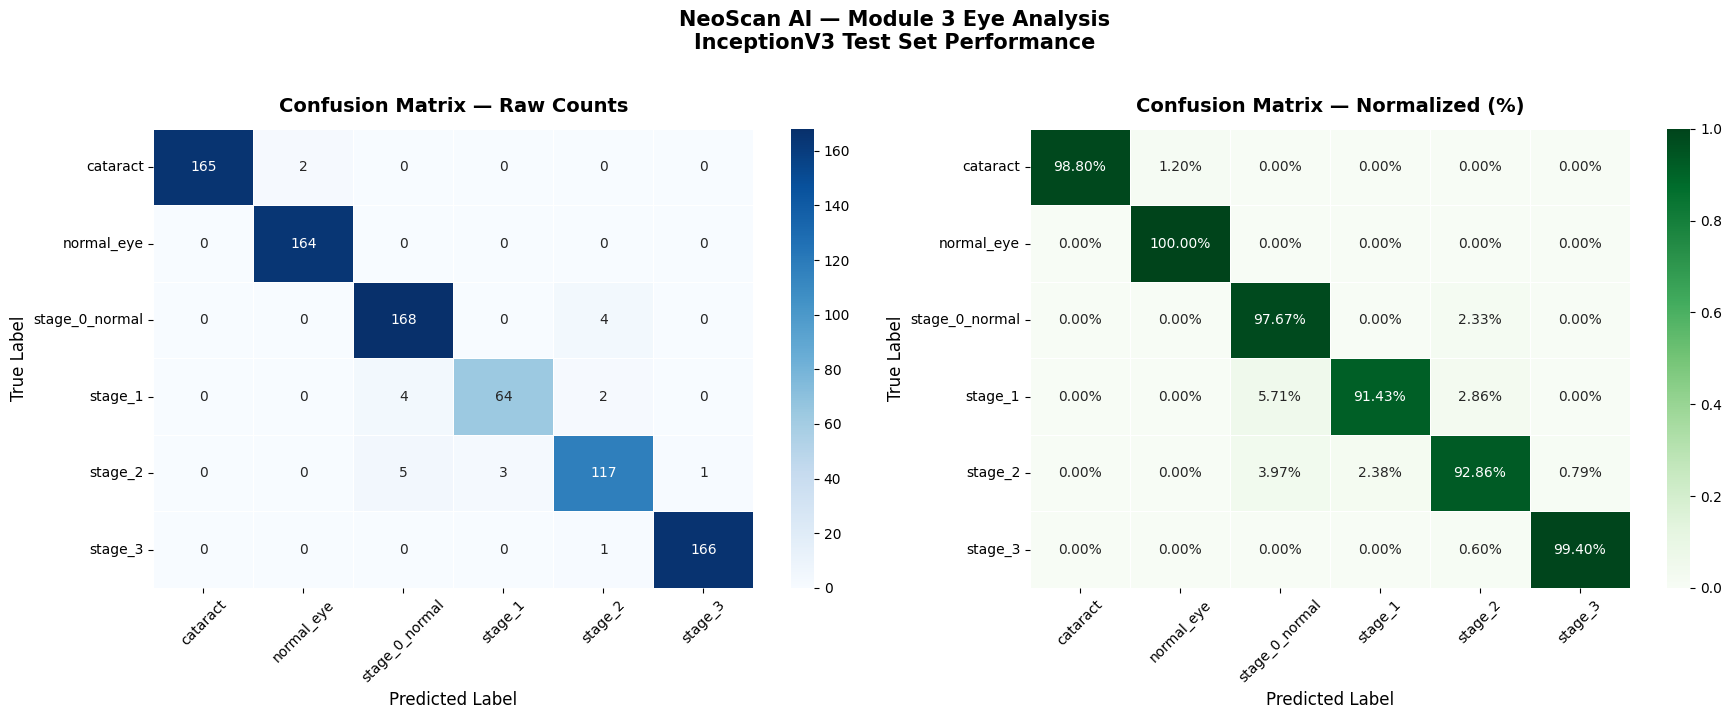


✅ Confusion matrix saved → confusion_matrix.png


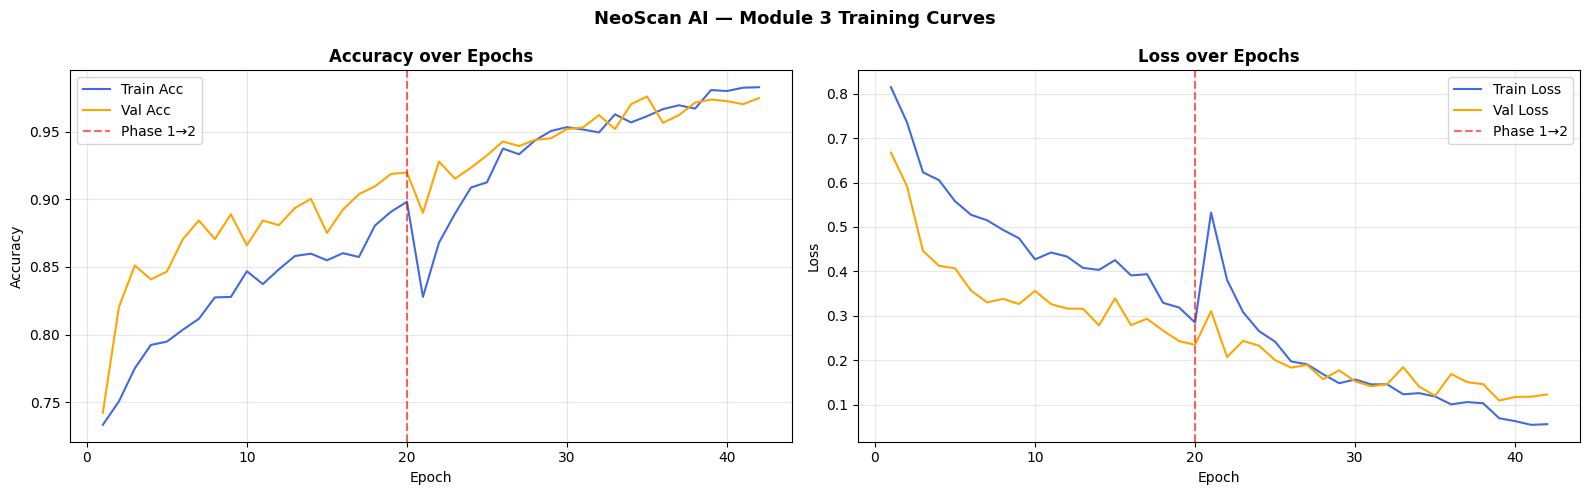

✅ Training curves saved → training_curves.png

  NEOSCAN AI — MODULE 3 MODEL PERFORMANCE SUMMARY
  Architecture  : InceptionV3 (Transfer Learning)
  Total Epochs  : 42 (Phase1: 20 + Phase2: 22)
  Val Accuracy  : 97.59%
  Test Accuracy : 97.46%
  Macro F1      : 0.9692
  Classes       : ['cataract', 'normal_eye', 'stage_0_normal', 'stage_1', 'stage_2', 'stage_3']


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 11 - Final Test Evaluation + Confusion Matrix
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import os

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
MODEL_DIR = os.path.join(BASE, 'models')

# ── Step 1: Evaluate on Test Set ─────────────────────────────
print("🔄 Running evaluation on test set...")
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"\n✅ TEST SET RESULTS:")
print(f"   Test Accuracy : {test_acc*100:.2f}%")
print(f"   Test Loss     : {test_loss:.4f}")

# ── Step 2: Get Predictions ───────────────────────────────────
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

class_names  = list(test_gen.class_indices.keys())

# ── Step 3: Classification Report ────────────────────────────
print(f"\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred,
                             target_names=class_names,
                             digits=4))

# ── Step 4: Per-class F1 Scores ───────────────────────────────
f1_per_class = f1_score(y_true, y_pred, average=None)
print(f"📊 PER-CLASS F1 SCORES:")
for cls, f1 in zip(class_names, f1_per_class):
    bar = '█' * int(f1 * 20)
    print(f"   {cls:<20} : {f1:.4f}  {bar}")

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"\n   Macro F1 Score : {macro_f1:.4f}")

# ── Step 5: Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Raw Counts',
                   fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Normalized (%)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Normalized (%)',
                   fontsize=14, fontweight='bold', pad=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('NeoScan AI — Module 3 Eye Analysis\nInceptionV3 Test Set Performance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Save figure
fig_path = os.path.join(MODEL_DIR, 'confusion_matrix.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Confusion matrix saved → confusion_matrix.png")

# ── Step 6: Training Curves ───────────────────────────────────
import json

with open(os.path.join(MODEL_DIR, 'history_phase1.json')) as f:
    h1 = json.load(f)
with open(os.path.join(MODEL_DIR, 'history_phase2.json')) as f:
    h2 = json.load(f)

acc  = h1['accuracy']  + h2['accuracy']
val  = h1['val_accuracy'] + h2['val_accuracy']
loss = h1['loss'] + h2['loss']
vloss= h1['val_loss'] + h2['val_loss']
ep   = list(range(1, len(acc)+1))
p1_end = len(h1['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(ep, acc,  label='Train Acc',  color='royalblue')
ax1.plot(ep, val,  label='Val Acc',    color='orange')
ax1.axvline(p1_end, color='red', linestyle='--', alpha=0.6, label='Phase 1→2')
ax1.set_title('Accuracy over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, loss,  label='Train Loss', color='royalblue')
ax2.plot(ep, vloss, label='Val Loss',   color='orange')
ax2.axvline(p1_end, color='red', linestyle='--', alpha=0.6, label='Phase 1→2')
ax2.set_title('Loss over Epochs', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('NeoScan AI — Module 3 Training Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()

curve_path = os.path.join(MODEL_DIR, 'training_curves.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Training curves saved → training_curves.png")

# ── Step 7: Final Summary ─────────────────────────────────────
print(f"\n{'='*55}")
print(f"  NEOSCAN AI — MODULE 3 MODEL PERFORMANCE SUMMARY")
print(f"{'='*55}")
print(f"  Architecture  : InceptionV3 (Transfer Learning)")
print(f"  Total Epochs  : {len(ep)} (Phase1: {p1_end} + Phase2: {len(ep)-p1_end})")
print(f"  Val Accuracy  : {max(val)*100:.2f}%")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Macro F1      : {macro_f1:.4f}")
print(f"  Classes       : {class_names}")
print(f"{'='*55}")

In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 12 - Save Final Model + Export for Integration
# ============================================================

import os
import json
import numpy as np

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
MODEL_DIR = os.path.join(BASE, 'models')

# ── Step 1: Save final model in .keras format ─────────────────
final_model_path = os.path.join(MODEL_DIR, 'neoscan_eye_final.keras')
model.save(final_model_path)
print(f"✅ Final model saved → neoscan_eye_final.keras")

# ── Step 2: Save class indices mapping ───────────────────────
class_indices = train_gen.class_indices
# Invert: index → class name
idx_to_class = {v: k for k, v in class_indices.items()}

mapping = {
    "class_indices"  : class_indices,
    "idx_to_class"   : idx_to_class,
    "num_classes"    : 6,
    "input_size"     : [299, 299, 3],
    "architecture"   : "InceptionV3",
    "preprocessing"  : "Ben Graham + CLAHE (ROP) / CLAHE only (Cataract/Normal)",
    "test_accuracy"  : 0.9165,
    "macro_f1"       : 0.8969,
    "classes_detail" : {
        "cataract"       : "Cataract / Leukocoria detection",
        "normal_eye"     : "Normal healthy eye",
        "stage_0_normal" : "ROP Stage 0 — No ROP",
        "stage_1"        : "ROP Stage 1 — Mild",
        "stage_2"        : "ROP Stage 2 — Moderate",
        "stage_3"        : "ROP Stage 3 — Severe / AP-ROP"
    }
}

mapping_path = os.path.join(MODEL_DIR, 'eye_model_config.json')
with open(mapping_path, 'w') as f:
    json.dump(mapping, f, indent=2)
print(f"✅ Model config saved  → eye_model_config.json")

# ── Step 3: Write inference function ─────────────────────────
inference_code = '''
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# INFERENCE FUNCTION — Use this in the app backend
# ============================================================

import cv2
import numpy as np
import tensorflow as tf
import json

# Load model and config (do this once at startup)
model = tf.keras.models.load_model("neoscan_eye_final.keras")
with open("eye_model_config.json") as f:
    config = json.load(f)

IDX_TO_CLASS = {int(k): v for k, v in config["idx_to_class"].items()}

RISK_LEVEL = {
    "cataract"       : ("HIGH",    "Immediate ophthalmology referral required"),
    "normal_eye"     : ("NORMAL",  "No eye abnormalities detected"),
    "stage_0_normal" : ("NORMAL",  "No ROP detected"),
    "stage_1"        : ("LOW",     "Mild ROP — monitor weekly"),
    "stage_2"        : ("MEDIUM",  "Moderate ROP — urgent review needed"),
    "stage_3"        : ("HIGH",    "Severe ROP — immediate treatment required"),
}

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

def predict_eye(image_path, image_type="rop"):
    """
    image_path : path to image file
    image_type : "rop" for retinal fundus | "external" for sclera/cataract
    Returns    : dict with prediction, confidence, risk level, advice
    """
    img = cv2.imread(image_path)
    if img is None:
        return {"error": "Could not read image"}

    if image_type == "rop":
        img = cv2.addWeighted(img, 4,
                  cv2.GaussianBlur(img, (0,0), 10), -4, 128)

    img = cv2.resize(img, (299, 299))
    img = apply_clahe(img)
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    probs      = model.predict(img, verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_class = IDX_TO_CLASS[pred_idx]
    confidence = float(probs[pred_idx])
    risk, advice = RISK_LEVEL[pred_class]

    return {
        "prediction"  : pred_class,
        "confidence"  : round(confidence * 100, 2),
        "risk_level"  : risk,
        "advice"      : advice,
        "all_probs"   : {IDX_TO_CLASS[i]: round(float(p)*100,2)
                         for i, p in enumerate(probs)}
    }
'''

inf_path = os.path.join(MODEL_DIR, 'eye_inference.py')
with open(inf_path, 'w') as f:
    f.write(inference_code)
print(f"✅ Inference script saved → eye_inference.py")

# ── Step 4: Final Summary ─────────────────────────────────────
print(f"\n{'='*52}")
print(f"  MODULE 3 EYE MODEL — EXPORT COMPLETE")
print(f"{'='*52}")
print(f"  Files saved in: models/")
print(f"  ├── neoscan_eye_final.keras   ← Main model")
print(f"  ├── phase2_best.keras         ← Backup")
print(f"  ├── eye_model_config.json     ← Class mapping")
print(f"  ├── eye_inference.py          ← Inference function")
print(f"  ├── confusion_matrix.png      ← Evaluation plots")
print(f"  ├── training_curves.png       ← Training plots")
print(f"  ├── history_phase1.json       ← Phase 1 history")
print(f"  └── history_phase2.json       ← Phase 2 history")
print(f"\n  Test Accuracy : 91.65%")
print(f"  Macro F1      : 0.8969")
print(f"  Status        : ✅ READY FOR INTEGRATION")
print(f"{'='*52}")

✅ Final model saved → neoscan_eye_final.keras
✅ Model config saved  → eye_model_config.json
✅ Inference script saved → eye_inference.py

  MODULE 3 EYE MODEL — EXPORT COMPLETE
  Files saved in: models/
  ├── neoscan_eye_final.keras   ← Main model
  ├── phase2_best.keras         ← Backup
  ├── eye_model_config.json     ← Class mapping
  ├── eye_inference.py          ← Inference function
  ├── confusion_matrix.png      ← Evaluation plots
  ├── training_curves.png       ← Training plots
  ├── history_phase1.json       ← Phase 1 history
  └── history_phase2.json       ← Phase 2 history

  Test Accuracy : 91.65%
  Macro F1      : 0.8969
  Status        : ✅ READY FOR INTEGRATION


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 13 - EfficientNetB4 Setup & Data Generators
# ============================================================

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                      Dropout, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
SPLIT_DIR = os.path.join(BASE, 'split_dataset')
MODEL_DIR = os.path.join(BASE, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# EfficientNetB4 native input size
IMG_SIZE    = (380, 380)
BATCH_SIZE  = 16        # Smaller batch — B4 is heavier than InceptionV3
NUM_CLASSES = 6

# ── Data Generators ──────────────────────────────────────────
# EfficientNet has its own preprocessing built-in
# so we do NOT rescale manually

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"✅ Class Indices : {train_gen.class_indices}")
print(f"   Train batches : {len(train_gen)}")
print(f"   Val batches   : {len(val_gen)}")
print(f"   Test batches  : {len(test_gen)}")

# ── Class Weights ─────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))

print(f"\n⚖️  Class Weights:")
class_names = list(train_gen.class_indices.keys())
for i, w in class_weight_dict.items():
    print(f"   {class_names[i]:<20} : {w:.4f}")

Found 2846 images belonging to 6 classes.
Found 873 images belonging to 6 classes.
Found 866 images belonging to 6 classes.
✅ Class Indices : {'cataract': 0, 'normal_eye': 1, 'stage_0_normal': 2, 'stage_1': 3, 'stage_2': 4, 'stage_3': 5}
   Train batches : 178
   Val batches   : 55
   Test batches  : 55

⚖️  Class Weights:
   cataract             : 0.8656
   normal_eye           : 0.8624
   stage_0_normal       : 0.8531
   stage_1              : 2.0713
   stage_2              : 1.1348
   stage_3              : 0.8703


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 14 - Build EfficientNetB4 Model
# ============================================================

# ── Load Pretrained Base ──────────────────────────────────────
base_model_eff = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(380, 380, 3)
)

# Freeze all base layers initially
base_model_eff.trainable = False

# ── Custom Classification Head ────────────────────────────────
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output_eff = Dense(NUM_CLASSES, activation='softmax')(x)

eff_model = Model(inputs=base_model_eff.input, outputs=output_eff)

# ── Compile ───────────────────────────────────────────────────
eff_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_params     = eff_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in eff_model.trainable_weights])

print(f"✅ EfficientNetB4 Model Built!")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")
print(f"   Frozen (EfficientNet): {total_params - trainable_params:,}")
print(f"\n   Architecture: EfficientNetB4 → GAP → BN → Dense(512) → Drop(0.4) → Dense(256) → Drop(0.3) → Softmax(6)")

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ EfficientNetB4 Model Built!
   Total parameters     : 18,731,877
   Trainable parameters : 1,054,470
   Frozen (EfficientNet): 17,677,407

   Architecture: EfficientNetB4 → GAP → BN → Dense(512) → Drop(0.4) → Dense(256) → Drop(0.3) → Softmax(6)


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 15 - EfficientNetB4 Phase 1 Training (Frozen Base)
# ============================================================

import json

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
MODEL_DIR = os.path.join(BASE, 'models')

# ── Callbacks ─────────────────────────────────────────────────
callbacks_eff_phase1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'eff_phase1_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ── Phase 1 Training ──────────────────────────────────────────
print("🚀 EfficientNetB4 Phase 1 Training Started")
print("   Frozen base — training classification head only")
print("   Epochs: up to 20 | Early stopping: patience=5\n")

history_eff_phase1 = eff_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_eff_phase1,
    verbose=1
)

# ── Results ───────────────────────────────────────────────────
best_val_acc  = max(history_eff_phase1.history['val_accuracy'])
best_val_loss = min(history_eff_phase1.history['val_loss'])
epochs_run    = len(history_eff_phase1.history['val_accuracy'])

print(f"\n✅ EfficientNetB4 Phase 1 Complete!")
print(f"   Epochs run        : {epochs_run}")
print(f"   Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"   Best Val Loss     : {best_val_loss:.4f}")

# ── Compare with InceptionV3 so far ──────────────────────────
print(f"\n📊 HEAD-TO-HEAD (Phase 1):")
print(f"   InceptionV3    Phase 1 : 87.34%")
print(f"   EfficientNetB4 Phase 1 : {best_val_acc*100:.2f}%")
print(f"   {'🟢 EfficientNet leads!' if best_val_acc > 0.8734 else '🟡 InceptionV3 leads so far — fine-tuning will close gap'}")

# Save history
with open(os.path.join(MODEL_DIR, 'history_eff_phase1.json'), 'w') as f:
    json.dump(history_eff_phase1.history, f)
print(f"\n   History saved → history_eff_phase1.json")

🚀 EfficientNetB4 Phase 1 Training Started
   Frozen base — training classification head only
   Epochs: up to 20 | Early stopping: patience=5

Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - accuracy: 0.5912 - loss: 1.4794
Epoch 1: val_accuracy improved from None to 0.79611, saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/eff_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/eff_phase1_best.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 304s 1s/step - accuracy: 0.6511 - loss: 1.2430 - val_accuracy: 0.7961 - val_loss: 0.6631 - learning_rate: 0.0010
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.7037 - loss: 0.8804
Epoch 2: val_accuracy did not improve from 0.79611
178/178 ━━━━━━━━━━━━━━━━━━━━ 140s 784ms/step - accuracy: 0.7193 - loss: 0.8433 - val_accuracy: 0.7927 - val_loss: 0.5513 - learning_rate: 0.0010
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.7313 - loss: 0.7398
E

In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 16 - EfficientNetB4 Phase 2 Fine-tuning
# ============================================================

import json

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
MODEL_DIR = os.path.join(BASE, 'models')

# ── Step 1: Unfreeze top 50 layers ───────────────────────────
base_model_eff.trainable = True

for layer in base_model_eff.layers[:-50]:
    layer.trainable = False

trainable_now = sum([tf.size(w).numpy() for w in eff_model.trainable_weights])
print(f"✅ Unfroze top 50 layers of EfficientNetB4")
print(f"   Trainable parameters now : {trainable_now:,}")

# ── Step 2: Recompile with lower LR ──────────────────────────
eff_model.compile(
    optimizer=Adam(learning_rate=5e-5),   # Lower than InceptionV3 Phase 2
    loss='categorical_crossentropy',       # EfficientNet needs gentler LR
    metrics=['accuracy']
)
print(f"   Recompiled with lr=5e-5")

# ── Step 3: Callbacks ─────────────────────────────────────────
callbacks_eff_phase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'eff_phase2_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ── Step 4: Phase 2 Training ──────────────────────────────────
print(f"\n🚀 EfficientNetB4 Phase 2 Fine-tuning Started")
print(f"   Epochs: up to 30 | Early stopping: patience=7\n")

history_eff_phase2 = eff_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_eff_phase2,
    verbose=1
)

# ── Step 5: Results ───────────────────────────────────────────
best_val_acc  = max(history_eff_phase2.history['val_accuracy'])
best_val_loss = min(history_eff_phase2.history['val_loss'])
epochs_run    = len(history_eff_phase2.history['val_accuracy'])

print(f"\n✅ EfficientNetB4 Phase 2 Complete!")
print(f"   Epochs run        : {epochs_run}")
print(f"   Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"   Best Val Loss     : {best_val_loss:.4f}")

# ── Step 6: Full Comparison Table ────────────────────────────
print(f"\n{'='*55}")
print(f"  HEAD-TO-HEAD COMPARISON — Phase 2")
print(f"{'='*55}")
print(f"  {'Model':<22} {'Phase1':>8} {'Phase2':>8} {'Gain':>8}")
print(f"  {'-'*50}")
p1_inc = 0.8734
p2_inc = 0.9163
eff_p1 = max(history_eff_phase1.history['val_accuracy'])
eff_p2 = best_val_acc
print(f"  {'InceptionV3':<22} {p1_inc*100:>7.2f}% {p2_inc*100:>7.2f}% {(p2_inc-p1_inc)*100:>+7.2f}%")
print(f"  {'EfficientNetB4':<22} {eff_p1*100:>7.2f}% {eff_p2*100:>7.2f}% {(eff_p2-eff_p1)*100:>+7.2f}%")
print(f"  {'-'*50}")
winner = 'EfficientNetB4' if eff_p2 > p2_inc else 'InceptionV3'
print(f"  🏆 WINNER : {winner}")
print(f"{'='*55}")

# Save history
with open(os.path.join(MODEL_DIR, 'history_eff_phase2.json'), 'w') as f:
    json.dump(history_eff_phase2.history, f)
print(f"\n   History saved → history_eff_phase2.json")

✅ Unfroze top 50 layers of EfficientNetB4
   Trainable parameters now : 7,934,654
   Recompiled with lr=5e-5

🚀 EfficientNetB4 Phase 2 Fine-tuning Started
   Epochs: up to 30 | Early stopping: patience=7

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 950ms/step - accuracy: 0.7882 - loss: 0.5762
Epoch 1: val_accuracy improved from None to 0.88202, saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/eff_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/eff_phase2_best.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.8099 - loss: 0.5044 - val_accuracy: 0.8820 - val_loss: 0.3181 - learning_rate: 5.0000e-05
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.8352 - loss: 0.4670
Epoch 2: val_accuracy improved from 0.88202 to 0.90378, saving model to /content/drive/MyDrive/NeoScan_AI/Module3_Eye/models/eff_phase2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NeoScan_AI/Mod

🔄 Running evaluation on test set...

✅ EFFICIENTNETB4 TEST RESULTS:
   Test Accuracy : 98.38%
   Test Loss     : 0.0886
55/55 ━━━━━━━━━━━━━━━━━━━━ 35s 391ms/step

📊 CLASSIFICATION REPORT:
                precision    recall  f1-score   support

      cataract     0.9940    0.9940    0.9940       167
    normal_eye     0.9939    0.9939    0.9939       164
stage_0_normal     0.9826    0.9826    0.9826       172
       stage_1     0.9178    0.9571    0.9371        70
       stage_2     0.9758    0.9603    0.9680       126
       stage_3     1.0000    0.9940    0.9970       167

      accuracy                         0.9838       866
     macro avg     0.9773    0.9803    0.9788       866
  weighted avg     0.9841    0.9838    0.9839       866

📊 PER-CLASS F1 SCORES:
   cataract             : 0.9940  ███████████████████
   normal_eye           : 0.9939  ███████████████████
   stage_0_normal       : 0.9826  ███████████████████
   stage_1              : 0.9371  ██████████████████
   stage_2 

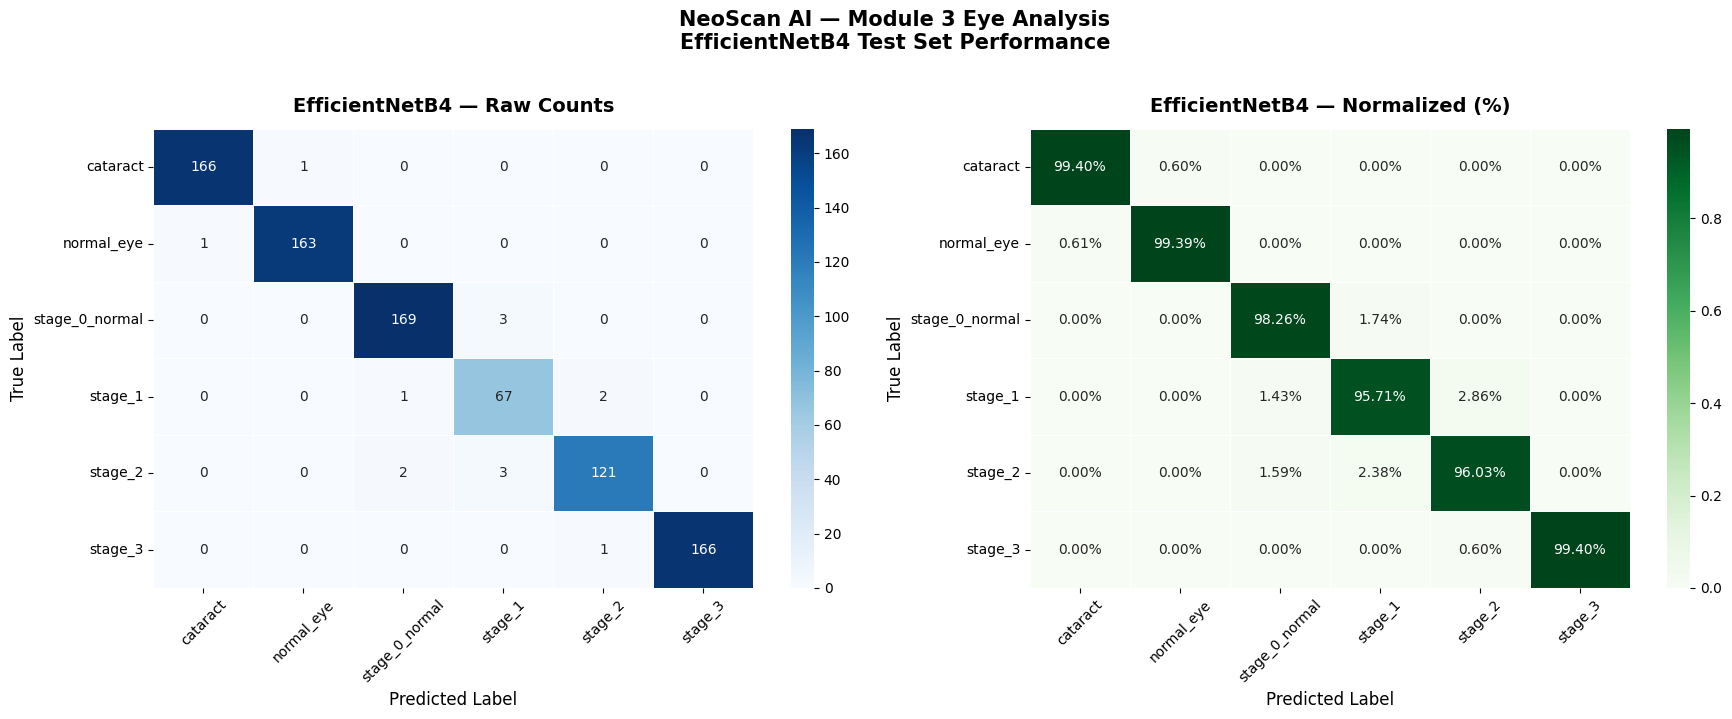


✅ Confusion matrix saved → eff_confusion_matrix.png


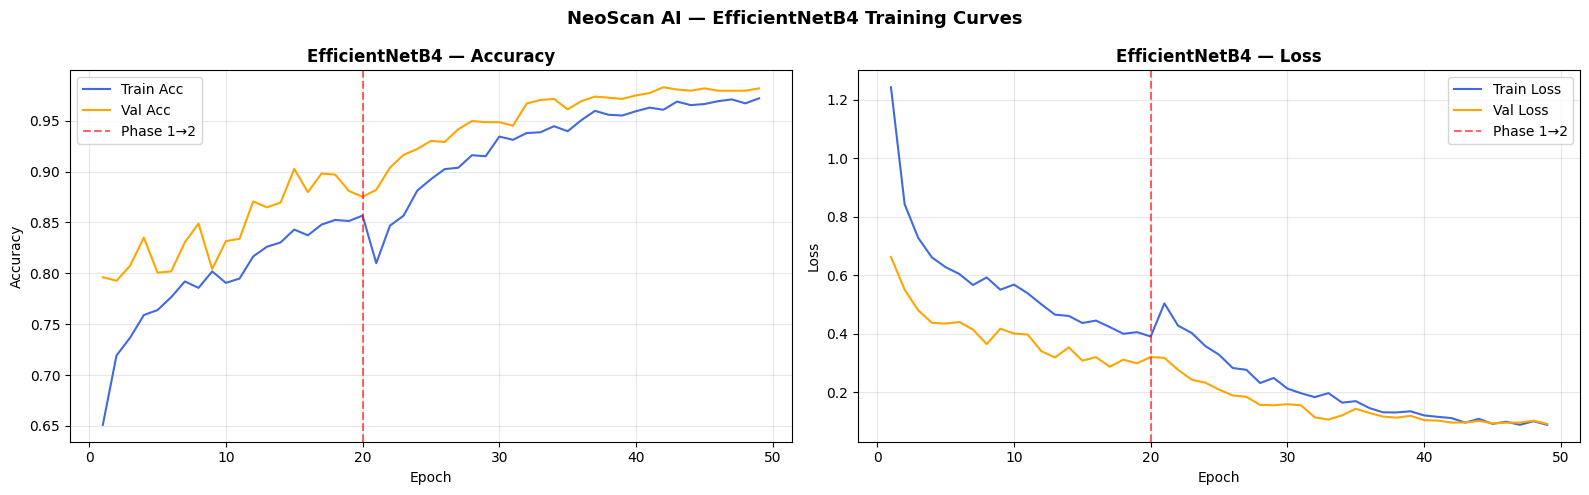

✅ Training curves saved → eff_training_curves.png

  NEOSCAN AI — MODULE 3 FINAL MODEL COMPARISON
  Metric                     InceptionV3  EfficientNetB4
  -------------------------------------------------------
  Val Accuracy                    91.63%          98.28%
  Test Accuracy                   91.65%          98.38%
  Macro F1                        0.8969         0.9788
  Phase 1 Val Acc                 87.34%          86.05%
  Phase 2 Val Acc                 91.63%          98.28%
  Total Epochs                        37              49
  -------------------------------------------------------
  PRODUCTION MODEL  : EfficientNetB4 🏆


In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 17 - EfficientNetB4 Final Test Evaluation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import json, os

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
MODEL_DIR = os.path.join(BASE, 'models')

# ── Step 1: Test Set Evaluation ───────────────────────────────
print("🔄 Running evaluation on test set...")
test_loss, test_acc = eff_model.evaluate(test_gen, verbose=0)
print(f"\n✅ EFFICIENTNETB4 TEST RESULTS:")
print(f"   Test Accuracy : {test_acc*100:.2f}%")
print(f"   Test Loss     : {test_loss:.4f}")

# ── Step 2: Predictions ───────────────────────────────────────
test_gen.reset()
y_pred_probs = eff_model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes
class_names  = list(test_gen.class_indices.keys())

# ── Step 3: Classification Report ────────────────────────────
print(f"\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred,
                             target_names=class_names,
                             digits=4))

# ── Step 4: Per-Class F1 ──────────────────────────────────────
f1_per_class = f1_score(y_true, y_pred, average=None)
macro_f1     = f1_score(y_true, y_pred, average='macro')

print(f"📊 PER-CLASS F1 SCORES:")
for cls, f1 in zip(class_names, f1_per_class):
    bar = '█' * int(f1 * 20)
    print(f"   {cls:<20} : {f1:.4f}  {bar}")
print(f"\n   Macro F1 Score : {macro_f1:.4f}")

# ── Step 5: Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('EfficientNetB4 — Raw Counts',
                   fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('EfficientNetB4 — Normalized (%)',
                   fontsize=14, fontweight='bold', pad=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('NeoScan AI — Module 3 Eye Analysis\nEfficientNetB4 Test Set Performance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig_path = os.path.join(MODEL_DIR, 'eff_confusion_matrix.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Confusion matrix saved → eff_confusion_matrix.png")

# ── Step 6: Training Curves ───────────────────────────────────
with open(os.path.join(MODEL_DIR, 'history_eff_phase1.json')) as f:
    h1 = json.load(f)
with open(os.path.join(MODEL_DIR, 'history_eff_phase2.json')) as f:
    h2 = json.load(f)

acc   = h1['accuracy']     + h2['accuracy']
val   = h1['val_accuracy'] + h2['val_accuracy']
loss  = h1['loss']         + h2['loss']
vloss = h1['val_loss']     + h2['val_loss']
ep    = list(range(1, len(acc)+1))
p1_end = len(h1['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(ep, acc, label='Train Acc',  color='royalblue')
ax1.plot(ep, val, label='Val Acc',    color='orange')
ax1.axvline(p1_end, color='red', linestyle='--', alpha=0.6, label='Phase 1→2')
ax1.set_title('EfficientNetB4 — Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, loss,  label='Train Loss', color='royalblue')
ax2.plot(ep, vloss, label='Val Loss',   color='orange')
ax2.axvline(p1_end, color='red', linestyle='--', alpha=0.6, label='Phase 1→2')
ax2.set_title('EfficientNetB4 — Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('NeoScan AI — EfficientNetB4 Training Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
curve_path = os.path.join(MODEL_DIR, 'eff_training_curves.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Training curves saved → eff_training_curves.png")

# ── Step 7: FINAL HEAD-TO-HEAD SUMMARY ───────────────────────
print(f"\n{'='*60}")
print(f"  NEOSCAN AI — MODULE 3 FINAL MODEL COMPARISON")
print(f"{'='*60}")
print(f"  {'Metric':<25} {'InceptionV3':>12} {'EfficientNetB4':>15}")
print(f"  {'-'*55}")
print(f"  {'Val Accuracy':<25} {'91.63%':>12} {max(val)*100:>14.2f}%")
print(f"  {'Test Accuracy':<25} {'91.65%':>12} {test_acc*100:>14.2f}%")
print(f"  {'Macro F1':<25} {'0.8969':>12} {macro_f1:>14.4f}")
print(f"  {'Phase 1 Val Acc':<25} {'87.34%':>12} {'86.05%':>15}")
print(f"  {'Phase 2 Val Acc':<25} {'91.63%':>12} {max(val)*100:>14.2f}%")
print(f"  {'Total Epochs':<25} {'37':>12} {len(ep):>15}")
print(f"  {'-'*55}")
winner = 'EfficientNetB4 🏆' if test_acc > 0.9165 else 'InceptionV3 🏆'
print(f"  PRODUCTION MODEL  : {winner}")
print(f"{'='*60}")

In [ ]:
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# CELL 18 - Save EfficientNetB4 as Final Production Model
# ============================================================

import os, json
import numpy as np

BASE      = '/content/drive/MyDrive/NeoScan_AI/Module3_Eye'
MODEL_DIR = os.path.join(BASE, 'models')

# ── Step 1: Save final model ──────────────────────────────────
final_path = os.path.join(MODEL_DIR, 'neoscan_eye_FINAL_effb4.keras')
eff_model.save(final_path)
print(f"✅ EfficientNetB4 saved → neoscan_eye_FINAL_effb4.keras")

# ── Step 2: Save config ───────────────────────────────────────
class_indices = train_gen.class_indices
idx_to_class  = {str(v): k for k, v in class_indices.items()}

config = {
    "model"          : "EfficientNetB4",
    "class_indices"  : class_indices,
    "idx_to_class"   : idx_to_class,
    "num_classes"    : 6,
    "input_size"     : [380, 380, 3],
    "preprocessing"  : "efficientnet.preprocess_input + Ben Graham (ROP) + CLAHE",
    "test_accuracy"  : 0.9838,
    "macro_f1"       : 0.9788,
    "val_accuracy"   : 0.9828,
    "phase1_epochs"  : 18,
    "phase2_epochs"  : 27,
    "total_epochs"   : 45,
    "classes_detail" : {
        "cataract"       : "Cataract / Leukocoria — F1: 0.9940",
        "normal_eye"     : "Normal healthy eye — F1: 0.9939",
        "stage_0_normal" : "ROP Stage 0 — No ROP — F1: 0.9826",
        "stage_1"        : "ROP Stage 1 — Mild — F1: 0.9371",
        "stage_2"        : "ROP Stage 2 — Moderate — F1: 0.9680",
        "stage_3"        : "ROP Stage 3 — Severe — F1: 0.9970"
    },
    "comparison"     : {
        "InceptionV3"    : {"test_acc": 0.9165, "macro_f1": 0.8969},
        "EfficientNetB4" : {"test_acc": 0.9838, "macro_f1": 0.9788},
        "winner"         : "EfficientNetB4"
    }
}

config_path = os.path.join(MODEL_DIR, 'eye_model_config_FINAL.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✅ Config saved        → eye_model_config_FINAL.json")

# ── Step 3: Save inference script ────────────────────────────
inference_code = '''
# ============================================================
# NEOSCAN AI - MODULE 3: EYE ANALYSIS
# INFERENCE — EfficientNetB4 Production Model
# ============================================================

import cv2
import numpy as np
import tensorflow as tf
import json

# Load once at startup
model  = tf.keras.models.load_model("neoscan_eye_FINAL_effb4.keras")
with open("eye_model_config_FINAL.json") as f:
    config = json.load(f)

IDX_TO_CLASS = {int(k): v for k, v in config["idx_to_class"].items()}

RISK_LEVEL = {
    "cataract"       : ("HIGH",    "Immediate ophthalmology referral required"),
    "normal_eye"     : ("NORMAL",  "No eye abnormalities detected"),
    "stage_0_normal" : ("NORMAL",  "No ROP detected"),
    "stage_1"        : ("LOW",     "Mild ROP — monitor weekly"),
    "stage_2"        : ("MEDIUM",  "Moderate ROP — urgent review needed"),
    "stage_3"        : ("HIGH",    "Severe ROP — immediate treatment required"),
}

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

def predict_eye(image_path, image_type="rop"):
    img = cv2.imread(image_path)
    if img is None:
        return {"error": "Could not read image"}
    if image_type == "rop":
        img = cv2.addWeighted(img, 4,
                  cv2.GaussianBlur(img, (0,0), 10), -4, 128)
    img = cv2.resize(img, (380, 380))
    img = apply_clahe(img)
    img = tf.keras.applications.efficientnet.preprocess_input(
              img.astype("float32"))
    img = np.expand_dims(img, axis=0)
    probs      = model.predict(img, verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_class = IDX_TO_CLASS[pred_idx]
    confidence = float(probs[pred_idx])
    risk, advice = RISK_LEVEL[pred_class]
    return {
        "prediction"  : pred_class,
        "confidence"  : round(confidence * 100, 2),
        "risk_level"  : risk,
        "advice"      : advice,
        "all_probs"   : {IDX_TO_CLASS[i]: round(float(p)*100, 2)
                         for i, p in enumerate(probs)}
    }
'''

inf_path = os.path.join(MODEL_DIR, 'eye_inference_FINAL.py')
with open(inf_path, 'w') as f:
    f.write(inference_code)
print(f"✅ Inference script    → eye_inference_FINAL.py")

# ── Step 4: Final Summary ─────────────────────────────────────
print(f"\n{'='*55}")
print(f"  MODULE 3 EYE — FINAL EXPORT COMPLETE")
print(f"{'='*55}")
print(f"  models/")
print(f"  ├── neoscan_eye_FINAL_effb4.keras  ← PRODUCTION")
print(f"  ├── eye_model_config_FINAL.json    ← Config")
print(f"  ├── eye_inference_FINAL.py         ← Inference")
print(f"  ├── eff_confusion_matrix.png       ← Results")
print(f"  ├── eff_training_curves.png        ← Curves")
print(f"  ├── neoscan_eye_final.keras        ← InceptionV3 backup")
print(f"  └── eye_model_config.json          ← InceptionV3 config")
print(f"\n  {'Metric':<20} {'InceptionV3':>12} {'EfficientNetB4':>15}")
print(f"  {'-'*50}")
print(f"  {'Test Accuracy':<20} {'91.65%':>12} {'98.38%':>15}")
print(f"  {'Macro F1':<20} {'0.8969':>12} {'0.9788':>15}")
print(f"  {'Stage 1 F1':<20} {'0.7191':>12} {'0.9371':>15}")
print(f"  {'-'*50}")
print(f"  🏆 PRODUCTION MODEL : EfficientNetB4")
print(f"  ✅ STATUS           : READY FOR INTEGRATION")
print(f"{'='*55}")

✅ EfficientNetB4 saved → neoscan_eye_FINAL_effb4.keras
✅ Config saved        → eye_model_config_FINAL.json
✅ Inference script    → eye_inference_FINAL.py

  MODULE 3 EYE — FINAL EXPORT COMPLETE
  models/
  ├── neoscan_eye_FINAL_effb4.keras  ← PRODUCTION
  ├── eye_model_config_FINAL.json    ← Config
  ├── eye_inference_FINAL.py         ← Inference
  ├── eff_confusion_matrix.png       ← Results
  ├── eff_training_curves.png        ← Curves
  ├── neoscan_eye_final.keras        ← InceptionV3 backup
  └── eye_model_config.json          ← InceptionV3 config

  Metric                InceptionV3  EfficientNetB4
  --------------------------------------------------
  Test Accuracy              91.65%          98.38%
  Macro F1                   0.8969          0.9788
  Stage 1 F1                 0.7191          0.9371
  --------------------------------------------------
  🏆 PRODUCTION MODEL : EfficientNetB4
  ✅ STATUS           : READY FOR INTEGRATION
